In [4]:
!pip install kagglehub tensorflow opencv-python matplotlib

import kagglehub
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from google.colab import files

# -----------------------------
# Step 1: Download dataset
# -----------------------------
path = kagglehub.dataset_download("iamtushara/face-detection-dataset")
print("Dataset path:", path)

# -----------------------------
# Step 2: Prepare data
# -----------------------------
IMG_SIZE = 64

data = []
labels = []

# Go through dataset folders
for root, dirs, files_list in os.walk(path):
    for file in files_list:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img)

            # Label: assume all images in dataset are faces
            labels.append(1)

# Add some random non-face images
for i in range(len(data)//2):
    noise = np.random.randint(0,255,(IMG_SIZE,IMG_SIZE,3),dtype=np.uint8)
    data.append(noise)
    labels.append(0)

# Convert to numpy
X = np.array(data) / 255.0
y = np.array(labels)

# Shuffle
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

# Split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Training samples:", len(X_train))

# -----------------------------
# Step 3: Build CNN
# -----------------------------
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# -----------------------------
# Step 4: Train
# -----------------------------
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Resuming download from 2023751680 bytes (4572379630 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/iamtushara/face-detection-dataset/1.archive (2023751680/6596131310) bytes left.


100%|██████████| 6.14G/6.14G [00:31<00:00, 146MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/iamtushara/face-detection-dataset/versions/1
Training samples: 39406


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9957 - loss: 0.0092 - val_accuracy: 1.0000 - val_loss: 2.9240e-06
Epoch 2/5
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 1.0000 - loss: 1.2444e-06 - val_accuracy: 1.0000 - val_loss: 4.3664e-07
Epoch 3/5
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 1.0000 - loss: 2.9477e-07 - val_accuracy: 1.0000 - val_loss: 1.2301e-07
Epoch 4/5
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 1.0000 - loss: 1.0929e-07 - val_accuracy: 1.0000 - val_loss: 5.1734e-08
Epoch 5/5
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 1.0000 - loss: 3.9962e-08 - val_accuracy: 1.0000 - val_loss: 2.0770e-08


Saving download.png to download.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━

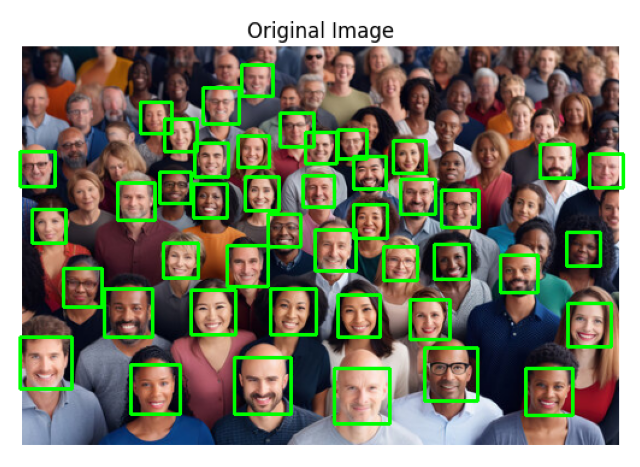

In [5]:
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Haar Cascade for detecting faces
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5)

# Draw rectangles and verify with CNN
for (x, y, w, h) in faces:
    face_crop = img[y:y+h, x:x+w]
    face_resized = cv2.resize(face_crop, (64,64)) / 255.0
    face_resized = np.expand_dims(face_resized, axis=0)

    prediction = model.predict(face_resized)
    if prediction > 0.5:
        color = (0, 255, 0)  # green for face
        label = ""
    else:
        color = (0, 0, 255)  # red if not face
        label = "No Face"

    cv2.rectangle(img, (x, y), (x+w, y+h), color, 2)
    cv2.putText(img, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

# Show final image
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()